In [64]:
# Import Libs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Objectivies:

    . The product that was ordered the most.
    . The pair of product that was ordered the most.
    . The warehouse with the most order by qty and by price.
    . The seasons and their order freq.
    . The seasons with the most order price.
    . The customer that ordered the most.
    . The percentage of customer that were happy with the products ordered.
    . The month with the most orders.

In [65]:
# Load data
data = pd.read_csv('dirty_retail_data.csv')
data.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD182494,ID6197211592,2019-06-22,Thompson,"[('Lucent 330S', 1), ('Thunder line', 2), ('iS...",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True
1,ORD395518,ID0282825849,2019-12-29,Thompson,"[('Thunder line', 1), ('Universe Note', 2)]",9080,62.71,-37.802736,144.951118,0,9142.71,Summer,False,1.1621,it keeps dropping calls the wifi don't work th...,False
2,ORD494479,ID0579391891,2019-03-02,Nickolson,"[('Thunder line', 1), ('pearTV', 2)]",10670,65.87,-37.821302,144.957581,10,9668.87,Autumn,False,1.0949,five stars this is a great cheap phone.,True
3,ORD019224,ID4544561904,2019-01-12,Nickolson,"[('Universe Note', 1), ('Alcon 10', 2), ('Oliv...",24800,57.61,-37.811416,144.973073,15,21137.61,Summer,False,0.8571,charger did not fit the charger didn't fit.,False
4,ORD104032,ID6231506320,2019-11-28,Nickolson,"[('Universe Note', 1), ('Olivia x460', 1), ('i...",9145,75.54,37.823859,144.969892,25,6934.29,Spring,False,0.5867,four stars good,True


In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       500 non-null    object 
 1   customer_id                    500 non-null    object 
 2   date                           500 non-null    object 
 3   nearest_warehouse              500 non-null    object 
 4   shopping_cart                  500 non-null    object 
 5   order_price                    500 non-null    int64  
 6   delivery_charges               500 non-null    float64
 7   customer_lat                   500 non-null    float64
 8   customer_long                  500 non-null    float64
 9   coupon_discount                500 non-null    int64  
 10  order_total                    500 non-null    float64
 11  season                         500 non-null    object 
 12  is_expedited_delivery          500 non-null    boo

In [67]:
data.describe()

,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,distance_to_nearest_warehouse
count,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000
mean,25522.216000,76.658200,-35.835234,144.969494,10.890000,3.920967e+04,2.204224
std,86333.729169,14.481465,12.045393,0.022720,8.649134,2.741940e+05,8.812416
min,585.000000,46.350000,-37.827123,144.924967,0.000000,6.392900e+02,0.107800
25%,7050.000000,65.982500,-37.818222,144.953488,5.000000,6.454735e+03,0.751425
50%,12807.500000,76.310000,-37.812165,144.965357,10.000000,1.129396e+04,1.030100
75%,20360.000000,82.555000,-37.805364,144.983985,15.000000,1.811919e+04,1.408625
max,947691.000000,114.040000,37.826339,145.019837,25.000000,5.688270e+06,94.973400


In [68]:
# Data Cleaning
data['date'].unique()

array(['2019-06-22', '2019-12-29', '2019-03-02', '2019-01-12',
       '2019-11-28', '2019-09-16', '2019-09-14', '2019-05-23',
       '2019-10-09', '2019-03-21', '2019-08-03', '2019-12-05',
       '2019-02-11', '2019-12-24', '2019-04-09', '2019-05-17',
       '2019-08-10', '2019-07-15', '2019-02-24', '2019-01-04',
       '2019-11-20', '2019-12-15', '2019-09-17', '2019-10-07',
       '2019-04-07', '2019-11-19', '2019-01-05', '2019-06-24',
       '2019-02-26', '2019-03-01', '2019-07-25', '2019-04-26',
       '2019-12-17', '2019-04-14', '2019-08-27', '2019-06-26',
       '2019-04-02', '2019-10-17', '2019-03-08', '2019-02-02',
       '2019-12-21', '03-13-2019', '2019-03-28', '2019-12-19',
       '2019-02-14', '2019-09-28', '2019-06-03', '2019-05-27',
       '2019-01-18', '2019-01-28', '2019-08-26', '2019-09-07',
       '2019-05-05', '2019-09-26', '2019-05-30', '2019-06-13',
       '2019-09-03', '2019-04-25', '2019-01-02', '2019-10-25',
       '2019-11-04', '2019-02-22', '2019-10-16', '2019-

In [69]:
data['date'] = data['date'].str.replace(' ', '-')
data['date'].unique()

array(['2019-06-22', '2019-12-29', '2019-03-02', '2019-01-12',
       '2019-11-28', '2019-09-16', '2019-09-14', '2019-05-23',
       '2019-10-09', '2019-03-21', '2019-08-03', '2019-12-05',
       '2019-02-11', '2019-12-24', '2019-04-09', '2019-05-17',
       '2019-08-10', '2019-07-15', '2019-02-24', '2019-01-04',
       '2019-11-20', '2019-12-15', '2019-09-17', '2019-10-07',
       '2019-04-07', '2019-11-19', '2019-01-05', '2019-06-24',
       '2019-02-26', '2019-03-01', '2019-07-25', '2019-04-26',
       '2019-12-17', '2019-04-14', '2019-08-27', '2019-06-26',
       '2019-04-02', '2019-10-17', '2019-03-08', '2019-02-02',
       '2019-12-21', '03-13-2019', '2019-03-28', '2019-12-19',
       '2019-02-14', '2019-09-28', '2019-06-03', '2019-05-27',
       '2019-01-18', '2019-01-28', '2019-08-26', '2019-09-07',
       '2019-05-05', '2019-09-26', '2019-05-30', '2019-06-13',
       '2019-09-03', '2019-04-25', '2019-01-02', '2019-10-25',
       '2019-11-04', '2019-02-22', '2019-10-16', '2019-

In [1]:
data['date'] = pd.to_datetime(data['date'], format='mixed',dayfirst=False)
data['date'].dtype

NameError: name 'pd' is not defined

In [71]:
# or do this
data['date'] = pd.to_datetime(data['date'], format='mixed')
data['date'].dtype

dtype('<M8[ns]')

In [72]:
data['date'].unique()

<DatetimeArray>
['2019-06-22 00:00:00', '2019-12-29 00:00:00', '2019-03-02 00:00:00',
 '2019-01-12 00:00:00', '2019-11-28 00:00:00', '2019-09-16 00:00:00',
 '2019-09-14 00:00:00', '2019-05-23 00:00:00', '2019-10-09 00:00:00',
 '2019-03-21 00:00:00',
 ...
 '2019-11-09 00:00:00', '2019-12-02 00:00:00', '2019-04-03 00:00:00',
 '2019-10-24 00:00:00', '2019-08-18 00:00:00', '2019-12-28 00:00:00',
 '2019-12-27 00:00:00', '2019-09-18 00:00:00', '2019-04-05 00:00:00',
 '2019-05-19 00:00:00']
Length: 269, dtype: datetime64[ns]

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       500 non-null    object        
 1   customer_id                    500 non-null    object        
 2   date                           500 non-null    datetime64[ns]
 3   nearest_warehouse              500 non-null    object        
 4   shopping_cart                  500 non-null    object        
 5   order_price                    500 non-null    int64         
 6   delivery_charges               500 non-null    float64       
 7   customer_lat                   500 non-null    float64       
 8   customer_long                  500 non-null    float64       
 9   coupon_discount                500 non-null    int64         
 10  order_total                    500 non-null    float64       
 11  season             

In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       500 non-null    object        
 1   customer_id                    500 non-null    object        
 2   date                           500 non-null    datetime64[ns]
 3   nearest_warehouse              500 non-null    object        
 4   shopping_cart                  500 non-null    object        
 5   order_price                    500 non-null    int64         
 6   delivery_charges               500 non-null    float64       
 7   customer_lat                   500 non-null    float64       
 8   customer_long                  500 non-null    float64       
 9   coupon_discount                500 non-null    int64         
 10  order_total                    500 non-null    float64       
 11  season             

In [75]:
# future Engineering
# Got the month from the data cot
data['month'] = pd.to_datetime(data['date']).dt.month_name()

In [76]:
data['month']

0          June
1      December
2         March
3       January
4      November
         ...   
495      August
496       March
497     October
498         May
499         May
Name: month, Length: 500, dtype: object

In [77]:
# cleaned the nearest warehouse
data ['nearest_warehouse'].unique()

array(['Thompson', 'Nickolson', 'Bakers', 'nickolson', 'thompson'],
      dtype=object)

In [78]:
data['nearest_warehouse'] = data['nearest_warehouse'].str.title()

In [79]:
data['nearest_warehouse'].unique()

array(['Thompson', 'Nickolson', 'Bakers'], dtype=object)

In [80]:
data.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer,month
0,ORD182494,ID6197211592,2019-06-22,Thompson,"[('Lucent 330S', 1), ('Thunder line', 2), ('iS...",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June
1,ORD395518,ID0282825849,2019-12-29,Thompson,"[('Thunder line', 1), ('Universe Note', 2)]",9080,62.71,-37.802736,144.951118,0,9142.71,Summer,False,1.1621,it keeps dropping calls the wifi don't work th...,False,December
2,ORD494479,ID0579391891,2019-03-02,Nickolson,"[('Thunder line', 1), ('pearTV', 2)]",10670,65.87,-37.821302,144.957581,10,9668.87,Autumn,False,1.0949,five stars this is a great cheap phone.,True,March
3,ORD019224,ID4544561904,2019-01-12,Nickolson,"[('Universe Note', 1), ('Alcon 10', 2), ('Oliv...",24800,57.61,-37.811416,144.973073,15,21137.61,Summer,False,0.8571,charger did not fit the charger didn't fit.,False,January
4,ORD104032,ID6231506320,2019-11-28,Nickolson,"[('Universe Note', 1), ('Olivia x460', 1), ('i...",9145,75.54,37.823859,144.969892,25,6934.29,Spring,False,0.5867,four stars good,True,November


In [81]:
data['shopping_cart'].value_counts()

shopping_cart
[('iStream', 1), ('Candle Inferno', 2)]                                           3
[('iAssist Line', 1), ('Thunder line', 1)]                                        3
[('iStream', 1), ('Thunder line', 2)]                                             3
[('Lucent 330S', 2), ('iAssist Line', 1)]                                         2
[('Alcon 10', 2), ('Lucent 330S', 2)]                                             2
                                                                                 ..
[('Alcon 10', 1), ('Olivia x460', 2), ('Lucent 330S', 1), ('Thunder line', 1)]    1
[('Olivia x460', 1), ('Candle Inferno', 1)]                                       1
[('iAssist Line', 2), ('Candle Inferno', 2), ('Olivia x460', 1)]                  1
[('Thunder line', 2), ('iStream', 2), ('Olivia x460', 1)]                         1
[('pearTV', 2), ('iStream', 2)]                                                   1
Name: count, Length: 469, dtype: int64

In [82]:
data['shopping_cart'].nunique()

469

 Fix for stringified lists
we need to convert the string  before exploding.

ast.literal_eval is the safe way to convert them to real python objects before working with them.

In [83]:
import ast
data['shopping_cart'] = data['shopping_cart'].apply(ast.literal_eval)

data.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer,month
0,ORD182494,ID6197211592,2019-06-22,Thompson,"[(Lucent 330S, 1), (Thunder line, 2), (iStream...",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June
1,ORD395518,ID0282825849,2019-12-29,Thompson,"[(Thunder line, 1), (Universe Note, 2)]",9080,62.71,-37.802736,144.951118,0,9142.71,Summer,False,1.1621,it keeps dropping calls the wifi don't work th...,False,December
2,ORD494479,ID0579391891,2019-03-02,Nickolson,"[(Thunder line, 1), (pearTV, 2)]",10670,65.87,-37.821302,144.957581,10,9668.87,Autumn,False,1.0949,five stars this is a great cheap phone.,True,March
3,ORD019224,ID4544561904,2019-01-12,Nickolson,"[(Universe Note, 1), (Alcon 10, 2), (Olivia x4...",24800,57.61,-37.811416,144.973073,15,21137.61,Summer,False,0.8571,charger did not fit the charger didn't fit.,False,January
4,ORD104032,ID6231506320,2019-11-28,Nickolson,"[(Universe Note, 1), (Olivia x460, 1), (iStrea...",9145,75.54,37.823859,144.969892,25,6934.29,Spring,False,0.5867,four stars good,True,November


In [84]:
# step 1: Exploder so each tuple is on its own row
df = data.explode('shopping_cart', ignore_index=True)

# step 2: split tuple inton two columns safety
df['product'] = df['shopping_cart'].apply(lambda x: x[0])
df['quantity'] = df['shopping_cart'].apply(lambda x: x[1])

In [85]:
df.head()

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer,month,product,quantity
0,ORD182494,ID6197211592,2019-06-22,Thompson,"(Lucent 330S, 1)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,Lucent 330S,1
1,ORD182494,ID6197211592,2019-06-22,Thompson,"(Thunder line, 2)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,Thunder line,2
2,ORD182494,ID6197211592,2019-06-22,Thompson,"(iStream, 2)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,iStream,2
3,ORD182494,ID6197211592,2019-06-22,Thompson,"(pearTV, 1)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,pearTV,1
4,ORD395518,ID0282825849,2019-12-29,Thompson,"(Thunder line, 1)",9080,62.71,-37.802736,144.951118,0,9142.71,Summer,False,1.1621,it keeps dropping calls the wifi don't work th...,False,December,Thunder line,1


In [86]:
#Q1
data['shopping_cart'].value_counts().head(1)

shopping_cart
[(iStream, 1), (Candle Inferno, 2)]    3
Name: count, dtype: int64

In [87]:
## df['shopping_cart'].head(1)

In [88]:
# Q2
df[df['product'] == df['product'].max()]

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer,month,product,quantity
184,ORD476072,ID0250774457,2019-09-26,Bakers,"(universe note, 1)",17765,67.96,-37.814798,145.011816,15,15168.21,Spring,False,1.5533,sad :( i emailed the seller and asked him if t...,False,September,universe note,1
582,ORD234525,ID0319159694,2019-07-21,Thompson,"(universe note, 1)",24860,66.68,-37.810154,144.957703,5,23683.68,Winter,False,0.9763,excellent excellent,True,July,universe note,1
1082,ORD285119,ID0052600120,2019-07-22,Thompson,"(universe note, 2)",13810,68.86,-37.802366,144.962057,5,13188.36,Winter,False,1.7476,awesome fone good fone,True,July,universe note,2


In [89]:
#Q3
df[df['nearest_warehouse'] == df['nearest_warehouse'].max()] 

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer,month,product,quantity
0,ORD182494,ID6197211592,2019-06-22,Thompson,"(Lucent 330S, 1)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,Lucent 330S,1
1,ORD182494,ID6197211592,2019-06-22,Thompson,"(Thunder line, 2)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,Thunder line,2
2,ORD182494,ID6197211592,2019-06-22,Thompson,"(iStream, 2)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,iStream,2
3,ORD182494,ID6197211592,2019-06-22,Thompson,"(pearTV, 1)",12200,79.89,-37.815105,144.932843,10,11059.89,Winter,True,1.2800,perfect phone and trusted seller. phone itself...,True,June,pearTV,1
4,ORD395518,ID0282825849,2019-12-29,Thompson,"(Thunder line, 1)",9080,62.71,-37.802736,144.951118,0,9142.71,Summer,False,1.1621,it keeps dropping calls the wifi don't work th...,False,December,Thunder line,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474,ORD118905,ID0711783633,2019-09-18,Thompson,"(Candle Inferno, 2)",11090,98.73,-37.816445,144.945805,0,11188.73,Spring,True,0.4343,"the one, the only...toshika! i've been a dedic...",True,September,Candle Inferno,2
1475,ORD118905,ID0711783633,2019-09-18,Thompson,"(Universe Note, 1)",11090,98.73,-37.816445,144.945805,0,11188.73,Spring,True,0.4343,"the one, the only...toshika! i've been a dedic...",True,September,Universe Note,1
1476,ORD118905,ID0711783633,2019-09-18,Thompson,"(Toshika 750, 1)",11090,98.73,-37.816445,144.945805,0,11188.73,Spring,True,0.4343,"the one, the only...toshika! i've been a dedic...",True,September,Toshika 750,1
1477,ORD161955,ID0036825302,2019-11-03,Thompson,"(Lucent 330S, 1)",2455,65.85,-37.825356,144.946242,15,2152.60,Spring,False,1.4137,this is a locked phone total fraud,False,November,Lucent 330S,1


In [90]:
# Highest_warehouse = data.groupby().sum[['shopping_cart', 'nearest_warehouse']]
#  Highest_warehouse

In [91]:
#  Q3
Highest_warehouse = data.groupby('nearest_warehouse')['order_total'].sum().idxmax()
Highest_warehouse 

'Bakers'

In [92]:
df['product'].unique()

array(['Lucent 330S', 'Thunder line', 'iStream', 'pearTV',
       'Universe Note', 'Alcon 10', 'Olivia x460', 'iAssist Line',
       'Toshika 750', 'Candle Inferno', 'iassist line', 'toshika 750',
       'olivia x460', 'universe note', 'IASSIST LINE', 'ALCON 10',
       'OLIVIA X460', 'ISTREAM', 'lucent 330s', 'thunder line', 'PEARTV',
       'LUCENT 330S', 'istream', 'peartv', 'CANDLE INFERNO',
       'THUNDER LINE', 'TOSHIKA 750', 'alcon 10', 'candle inferno'],
      dtype=object)

In [93]:
df['product'] = df['product'].str.lower()

In [94]:
df['product'].unique()

array(['lucent 330s', 'thunder line', 'istream', 'peartv',
       'universe note', 'alcon 10', 'olivia x460', 'iassist line',
       'toshika 750', 'candle inferno'], dtype=object)

ast.literal_eval is a python function from the ast (Abstract syntax trees) modules that safely evaluates  string containing a python literal (like a number, list,tuples, dict,string) into the actual python object.

what is explode()?explode () takes a column that contains (or thay iterable-like objects) and turns each element of those lists into  its own rows, while keeping all the other columnc the same.

In [95]:
# Q1. The product that was ordered the most.
most_ordered_product = df.groupby('product')['quantity'].sum().idxmax()
most_ordered_product

'lucent 330s'

In [96]:
# freq ordered
most_ordered_product = df['product'].value_counts()
most_ordered_product.to_csv("most_ordered_product.csv", encoding="utf-8", float_format="x.2F")
most_ordered_product

product
lucent 330s       164
thunder line      159
candle inferno    155
peartv            154
olivia x460       154
universe note     152
istream           145
alcon 10          143
toshika 750       143
iassist line      139
Name: count, dtype: int64

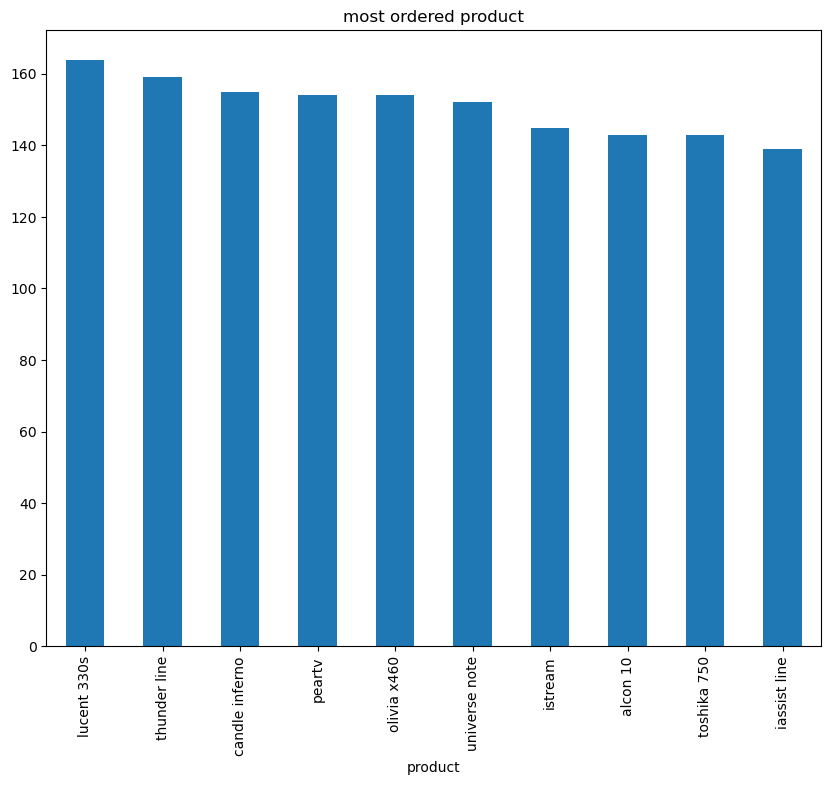

In [97]:
most_ordered_product.plot(kind="bar", figsize=(10,8))
plt.title('most ordered product')
plt.savefig('most ordered product.png', dpi=300, bbox_inches='tight')
plt.show()

In [98]:
# Q1. The product that was ordered the most.
most_ordered_product = df.groupby('product')['quantity'].sum().sort_values(ascending = False)

most_ordered_product

product
lucent 330s       246
peartv            242
universe note     237
thunder line      233
olivia x460       222
candle inferno    219
alcon 10          217
istream           213
toshika 750       211
iassist line      203
Name: quantity, dtype: int64

In [99]:
# freq ordered
most_ordered_product = df['product'].value_counts()
most_ordered_product

product
lucent 330s       164
thunder line      159
candle inferno    155
peartv            154
olivia x460       154
universe note     152
istream           145
alcon 10          143
toshika 750       143
iassist line      139
Name: count, dtype: int64

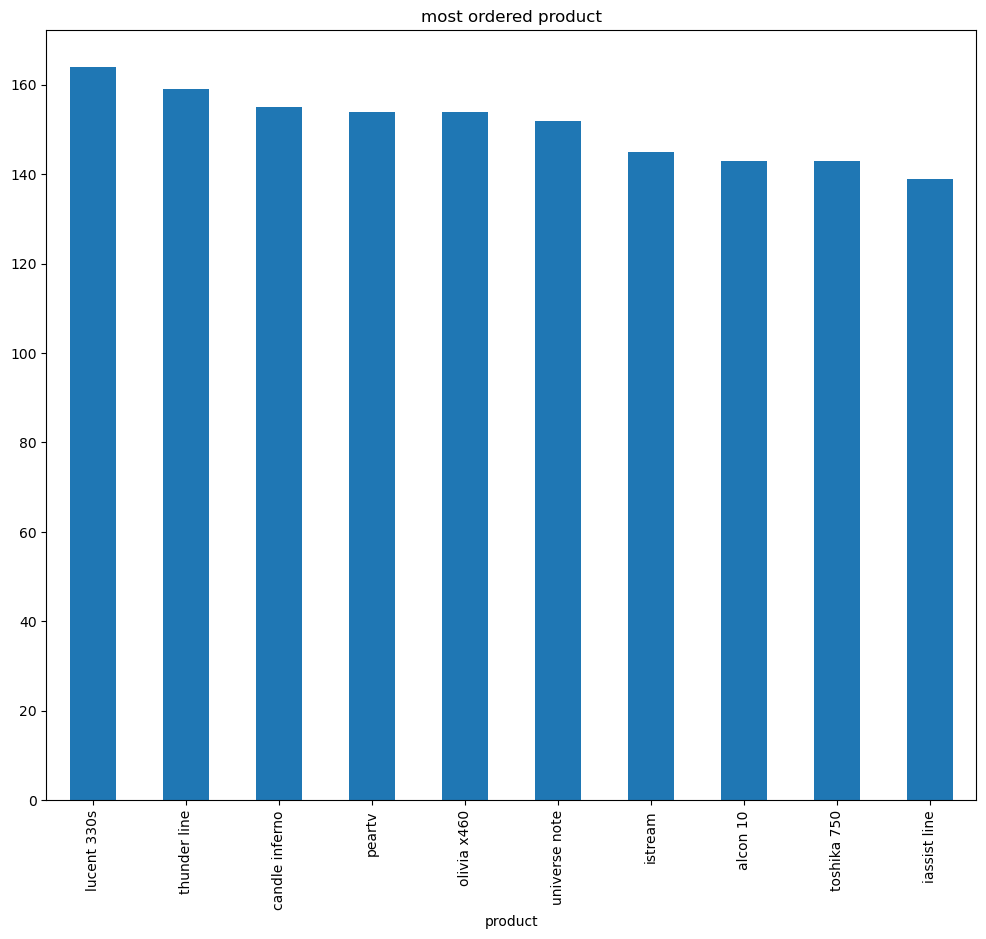

In [100]:
most_ordered_product.plot(kind="bar", figsize=(12,10))
plt.title('most ordered product')                         
plt.show()                          

Q2. The pair of products that was ordered the most.

In [101]:
pair_product_count = df.groupby(df['order_id'])[['product']].count()
pair_product_id = pair_product_count.idxmax()['product']
pair_product_id

'ORD004602'

In [102]:
pair_product = df[df['order_id'] == pair_product_id]
pair_product[['product', 'quantity']]

,product,quantity
810,thunder line,1
811,istream,1
812,lucent 330s,1
813,universe note,2


In [103]:
from itertools import combinations

pairs = []

for transaction_id, group in df.groupby('order_id'):
    products = group['product'].tolist()
    # Generate all pairs within this transaction
    for pair in combinations(sorted(products), 2):
        pairs.append(f"{pair[0]} & {pair[1]}")

# Count pairs
pair_counts = pd.Series(pairs).value_counts()
pair_counts.to_csv("product_pair_order.csv", encoding="utf-8", float_format="%.sf")
pair_counts.idxmax()

'alcon 10 & peartv'

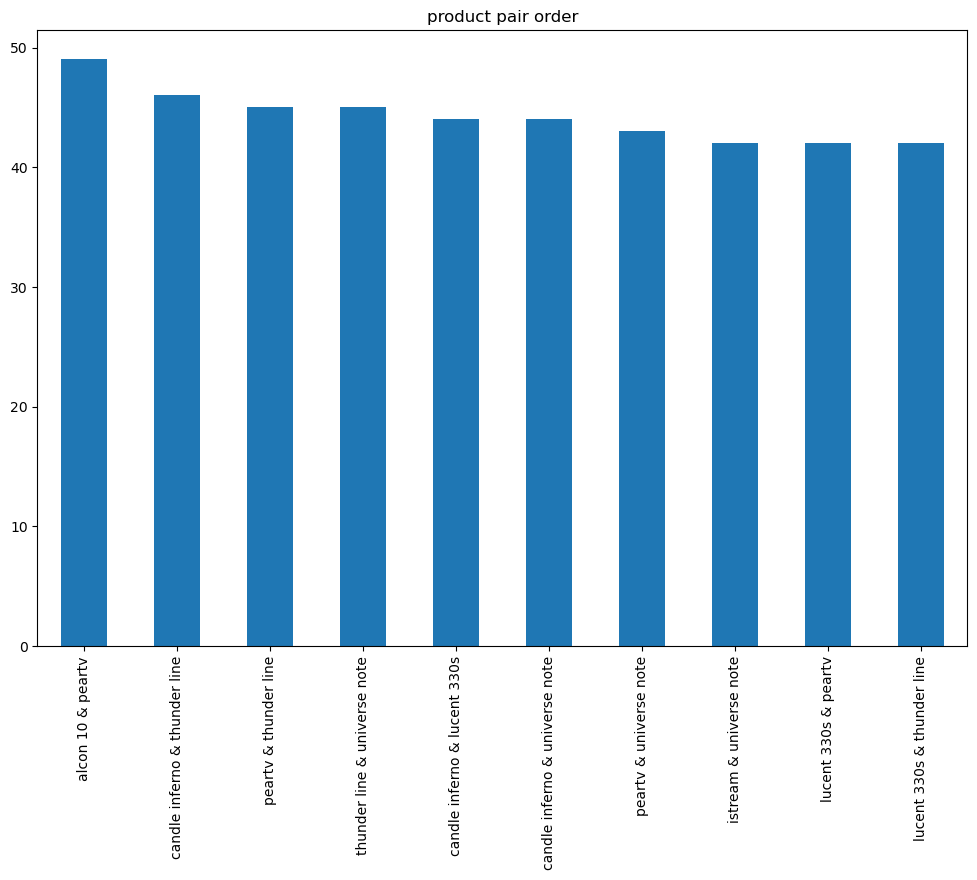

In [104]:
pair_counts.head(10).plot(kind="bar", figsize=(12,8))
plt.title("product pair order")
plt.savefig('product pair order.png', dpi=300, bbox_inches ='tight')
plt.show()            

In [105]:
# Q3. The warehouse with the most order by qty and by price.

In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       500 non-null    object        
 1   customer_id                    500 non-null    object        
 2   date                           500 non-null    datetime64[ns]
 3   nearest_warehouse              500 non-null    object        
 4   shopping_cart                  500 non-null    object        
 5   order_price                    500 non-null    int64         
 6   delivery_charges               500 non-null    float64       
 7   customer_lat                   500 non-null    float64       
 8   customer_long                  500 non-null    float64       
 9   coupon_discount                500 non-null    int64         
 10  order_total                    500 non-null    float64       
 11  season             

In [107]:
warehouse_most = df.groupby(df['nearest_warehouse'])[['order_price', 'quantity']].sum()
warehouse_most                             

,order_price,quantity
nearest_warehouse,,
Bakers,9066905,535
Nickolson,11671050,815
Thompson,22454171,893


In [108]:
warehouse_most_order = warehouse_most.idxmax()
warehouse_most_order

order_price    Thompson
quantity       Thompson
dtype: object

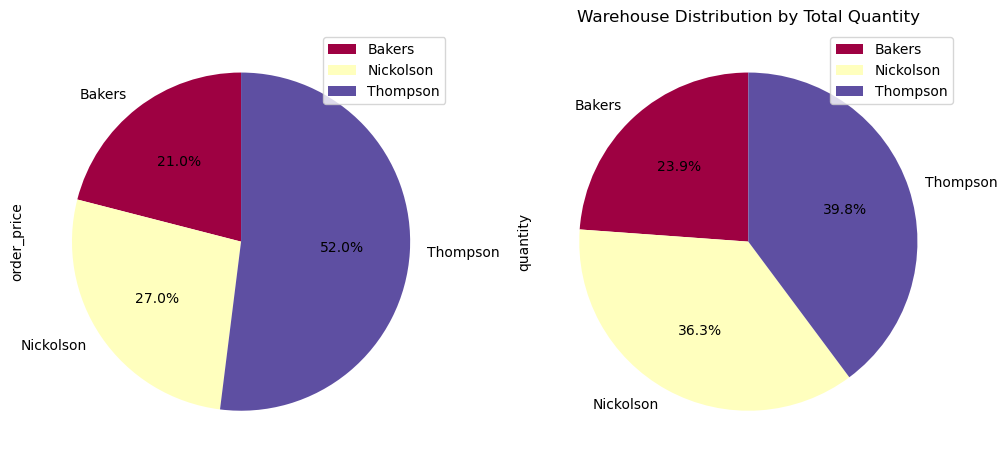

In [109]:
warehouse_most.plot(kind="pie", subplots=True, autopct='%1.1f%%', colormap="Spectral", startangle=90, figsize=(12, 15))
plt.title('Warehouse Distribution by Total Quantity')
plt.savefig('Warehouse Distribution by Total Quantity.png', dpi=300, bbox_inches='tight')                        

In [110]:
# Group by warehouse and calculate total
warehouse_summary = df.groupby('nearest_warehouse').agg({
    'quantity': ['sum', 'count', 'mean'],
    'order_price': ['sum', 'count', 'mean'],
    'order_id': 'nunique'  # count unique ordersnper warehouse
}).round(2)
warehouse_summary

quantity             order_price                 order_id
                       sum count  mean         sum count      mean  nunique
nearest_warehouse                                                          
Bakers                 535   352  1.52     9066905   352  25758.25      119
Nickolson              815   553  1.47    11671050   553  21104.97      184
Thompson               893   603  1.48    22454171   603  37237.43      197

In [111]:
# Q4 The seasons and their order freq.
df.season = df.season.str.title()

In [112]:
most_freq_season = df.season.value_counts()
most_freq_season

season
Spring    404
Autumn    384
Summer    376
Winter    344
Name: count, dtype: int64

In [113]:
# freq ordered
# df.groupby('season')['order_id'].count()

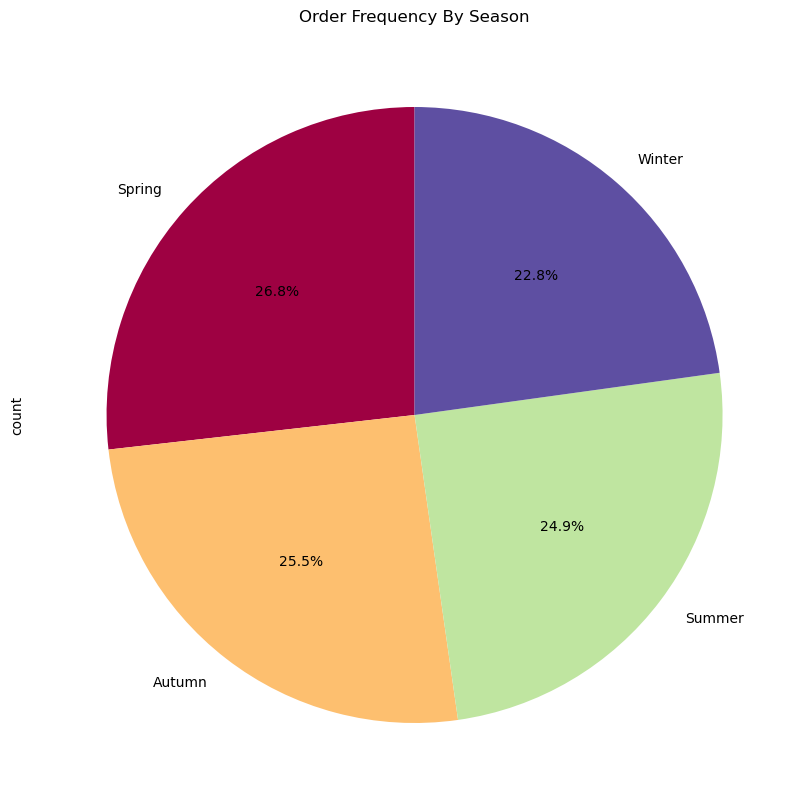

In [114]:
most_freq_season.plot(kind="pie", subplots=True, autopct='%1.1f%%', colormap="Spectral", startangle=90, figsize=(10, 10))
plt.title('Order Frequency By Season')                         
plt.savefig('Order Frequency By Season.png', dpi=300, bbox_inches='tight')            

Q5 The seasons with the most order price.

In [115]:
season_with_most_order_price = df.groupby('season')[['order_price']].sum()
season_with_most_order_price

,order_price
season,
Autumn,8590738
Spring,8202068
Summer,15702893
Winter,10696427


In [116]:
season_with_most_order_price.idxmax()

order_price    Summer
dtype: object

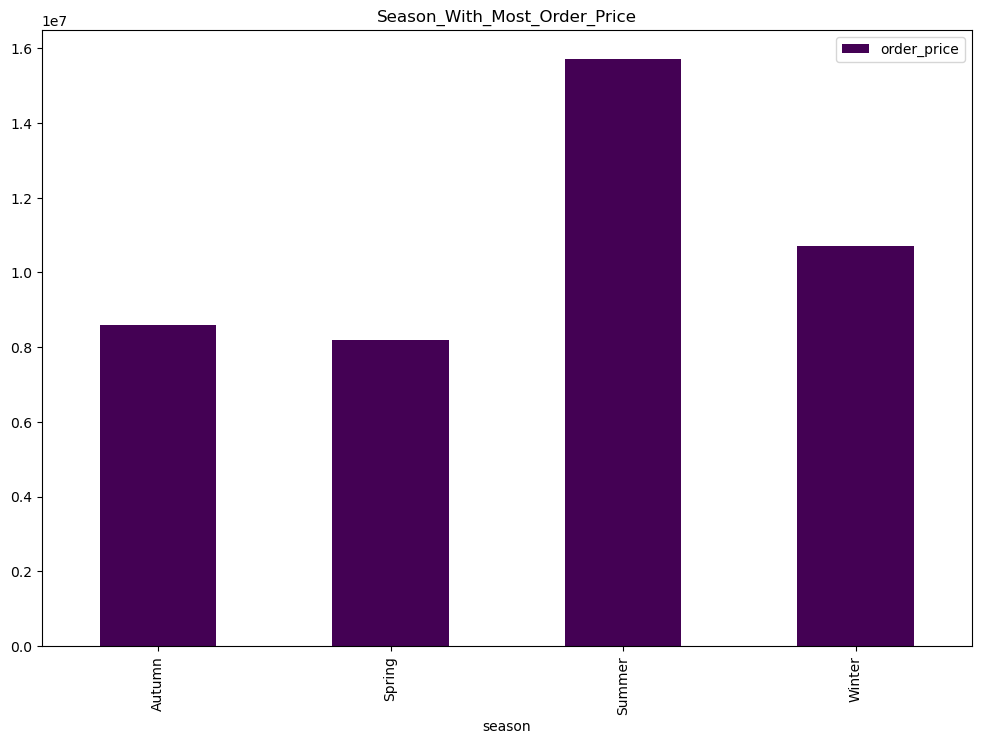

In [117]:
season_with_most_order_price.plot(kind="bar", figsize=(12, 8), colormap="viridis")
plt.title("Season_With_Most_Order_Price")                         
plt.savefig('Season_With_Most_Order_Price.png', dpi=300, bbox_inches='tight')       

Q5. The customer that ordered the most.

In [118]:
most_ordered_customer = df.groupby('customer_id')[['product', 'order_id']].count()

most_ordered_customer

,product,order_id
customer_id,,
ID0026051948,2,2
ID0030385486,3,3
ID0030385740,4,4
ID0030945778,3,3
ID0030946633,2,2
...,...,...
ID6226013492,2,2
ID6231506306,2,2
ID6231506320,4,4


In [119]:
most_ordered_customer.idxmax()

product     ID0591274456
order_id    ID0591274456
dtype: object

Q7. the percentage of customers that were happy with the products ordered

In [120]:
happy_customer = df[df.is_happy_customer == True]
count_happy_customer = len(happy_customer)
count_happy_customer

1077

In [121]:
percent_happy = (count_happy_customer/len(df))* 100
percent_happy

71.41909814323607

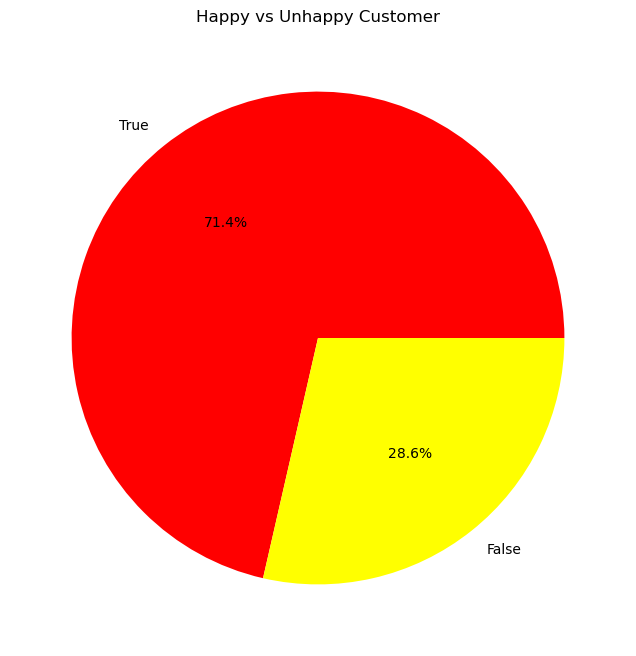

In [122]:
count_happy_customer = df['is_happy_customer'].value_counts()
count_happy_customer
plt.figure(figsize=(8, 8))
plt.pie(count_happy_customer, labels=count_happy_customer.index,colors=['red','yellow',], autopct='%1.1f%%')
plt.title("Happy vs Unhappy Customer")
plt.savefig('Happy vs Unhappy Customer.png', dpi=300, bbox_inches='tight') 

Q8.  The month with the most orders.

In [123]:
month_with_most_order = df['month'].value_counts()
month_with_most_order

month
September    157
January      141
October      138
April        135
May          133
February     122
March        121
November     120
June         119
August       115
December     108
July          99
Name: count, dtype: int64

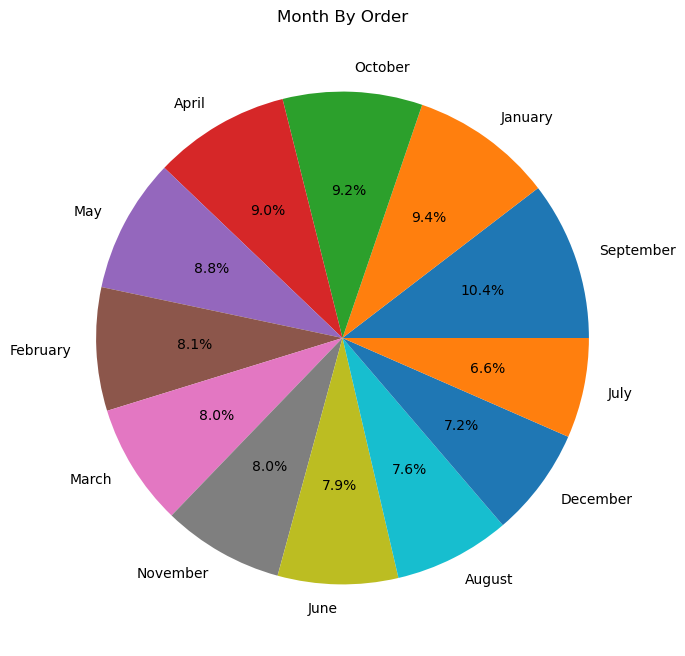

In [124]:
month_with_most_order.plot(kind="pie", autopct='%1.1f%%',figsize=(10, 8), ylabel="")
plt.title('Month By Order')
plt.savefig('Month By Order.png',dpi=300, bbox_inches='tight')

In [125]:
df['month'].value_counts()

month
September    157
January      141
October      138
April        135
May          133
February     122
March        121
November     120
June         119
August       115
December     108
July          99
Name: count, dtype: int64

'C:\\Users\\Ibukun\\Documents\\PANDAS 2'